# Portfolio Project: Online Retail Exploratory Data Analysis with Python

## Overview

In this project, you will step into the shoes of an entry-level data analyst at an online retail company, helping interpret real-world data to help make a key business decision.

## Case Study
In this project, you will be working with transactional data from an online retail store. The dataset contains information about customer purchases, including product details, quantities, prices, and timestamps. Your task is to explore and analyze this dataset to gain insights into the store's sales trends, customer behavior, and popular products. 

By conducting exploratory data analysis, you will identify patterns, outliers, and correlations in the data, allowing you to make data-driven decisions and recommendations to optimize the store's operations and improve customer satisfaction. Through visualizations and statistical analysis, you will uncover key trends, such as the busiest sales months, best-selling products, and the store's most valuable customers. Ultimately, this project aims to provide actionable insights that can drive strategic business decisions and enhance the store's overall performance in the competitive online retail market.

## Project Objectives
1. Describe data to answer key questions to uncover insights
2. Gain valuable insights that will help improve online retail performance
3. Provide analytic insights and data-driven recommendations

## Dataset

The dataset you will be working with is the "Online Retail" dataset. It contains transactional data of an online retail store from 2010 to 2011. The dataset is available as a .xlsx file named `Online Retail.xlsx`. This data file is already included in the Coursera Jupyter Notebook environment, however if you are working off-platform it can also be downloaded [here](https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx).

The dataset contains the following columns:

- InvoiceNo: Invoice number of the transaction
- StockCode: Unique code of the product
- Description: Description of the product
- Quantity: Quantity of the product in the transaction
- InvoiceDate: Date and time of the transaction
- UnitPrice: Unit price of the product
- CustomerID: Unique identifier of the customer
- Country: Country where the transaction occurred

## Tasks

You may explore this dataset in any way you would like - however if you'd like some help getting started, here are a few ideas:

1. Load the dataset into a Pandas DataFrame and display the first few rows to get an overview of the data.
2. Perform data cleaning by handling missing values, if any, and removing any redundant or unnecessary columns.
3. Explore the basic statistics of the dataset, including measures of central tendency and dispersion.
4. Perform data visualization to gain insights into the dataset. Generate appropriate plots, such as histograms, scatter plots, or bar plots, to visualize different aspects of the data.
5. Analyze the sales trends over time. Identify the busiest months and days of the week in terms of sales.
6. Explore the top-selling products and countries based on the quantity sold.
7. Identify any outliers or anomalies in the dataset and discuss their potential impact on the analysis.
8. Draw conclusions and summarize your findings from the exploratory data analysis.

## Task 1: Load the Data

In [ ]:
#import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [ ]:
#import the dataset using pandas
df = pd.read_excel("OnlineRetail.xlsx", usecols=["Description", "Quantity",	"InvoiceDate", "UnitPrice", "Country"])
df.head()


,Description,Quantity,InvoiceDate,UnitPrice,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom
1,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom


## Task 2: Data Cleaning (Missing and Duplicated Values)

In [ ]:
#first of all we need to check what features or columns working with
df.columns


Index(['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'Country'], dtype='object')

In [ ]:
# We need somme information about our data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Description  540455 non-null  object        
 1   Quantity     541909 non-null  int64         
 2   InvoiceDate  541909 non-null  datetime64[ns]
 3   UnitPrice    541909 non-null  float64       
 4   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 20.7+ MB


Here `541909`entries or rows, and Some columns have the missing `entries or values`, such as **Description** and **CustomerID** have the missing data.

In [ ]:
# We can check the type of the features
df.dtypes


Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
Country                object
dtype: object

Now we need to treat the `null value` as null value represents the missing value that can have an impact on our analysis.

In [ ]:
# To check how many null value do we have
df.isnull().sum()


Description    1454
Quantity          0
InvoiceDate       0
UnitPrice         0
Country           0
dtype: int64

You can can notice above we have missing data in the columns: **Description** and **CustomerID**.
the other columns have `zero missing values`.

In [ ]:
# Drope the NaN or missing value as they repressent nothing
df.dropna(axis=0, inplace=True)


In [ ]:
# Now we can check the missing value again
print(df.info())
print("")
print("The Number of Missing Data: ")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
Index: 540455 entries, 0 to 541908
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Description  540455 non-null  object        
 1   Quantity     540455 non-null  int64         
 2   InvoiceDate  540455 non-null  datetime64[ns]
 3   UnitPrice    540455 non-null  float64       
 4   Country      540455 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 24.7+ MB
None

The Number of Missing Data: 
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
Country        0
dtype: int64


Now there is no missing data We have drop or delete all the missing value.

We need to know if there is any `duplicates values`.

In [ ]:
# We can check duplicates values
df.duplicated().sum()


np.int64(6099)

In [ ]:
# Drop the duplicates values
df.drop_duplicates(inplace=True)


In [ ]:
# We can check duplicates values
df.duplicated().sum()


np.int64(0)

In [ ]:
# We can check which country represent in our data set
df["Country"].unique()


array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

## Task 3 Treating outliers
After treating the missing and duplicates values, and deleting somme columns we don't now detecting outliers.
Now it's time to explore our data to get deep insight about the data and detecting outliers.

<Axes: xlabel='Quantity', ylabel='UnitPrice'>

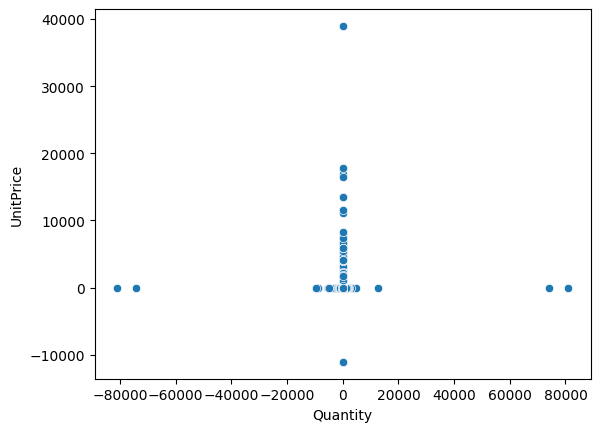

In [ ]:
# we can detect outiers using scatter plot
sns.scatterplot(x=df['Quantity'], y=df['UnitPrice'])


In [ ]:
#explore the data
df.describe()


,Quantity,InvoiceDate,UnitPrice
count,534356.000000,534356,534356.000000
mean,9.702429,2011-07-04 13:57:02.265231360,4.644569
min,-80995.000000,2010-12-01 08:26:00,-11062.060000
25%,1.000000,2011-03-28 11:49:00,1.250000
50%,3.000000,2011-07-20 10:08:00,2.080000
75%,10.000000,2011-10-19 10:31:15,4.130000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,218.825292,NaN,97.440329


In [ ]:
#Calculate assymetry
assymetry_Q = 3*(df['Quantity'].mean() - df['Quantity'].median())/df['Quantity'].std()
assymetry_P = 3*(df['UnitPrice'].mean() - df['UnitPrice'].median())/df['UnitPrice'].std()
assymetry_Q, assymetry_P



(np.float64(0.09188739547086887), np.float64(0.07895815240035524))

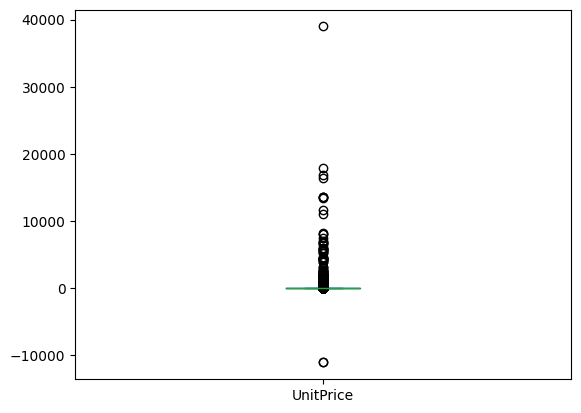

In [ ]:
# We can visualize Outliers using scatter plot
df["UnitPrice"].plot(kind='box')
plt.show()


In [ ]:
# To determine outlier using interquartile range
Q1_Quantity = df["Quantity"].quantile(0.25)
Q3_Quantity = df["Quantity"].quantile(0.75)
interquartile = Q3_Quantity - Q1_Quantity
mim_value = Q1_Quantity - 1.5*interquartile
max_value = Q3_Quantity + 1.5*interquartile
outliers_Quantity = df[(df['Quantity'] < mim_value) | (df['Quantity'] > max_value)]
outliers_Quantity


,Description,Quantity,InvoiceDate,UnitPrice,Country
9,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,United Kingdom
26,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,France
27,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,France
30,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,France
31,INFLATABLE POLITICAL GLOBE,48,2010-12-01 08:45:00,0.85,France
...,...,...,...,...,...
541876,MULTI COLOUR SILVER T-LIGHT HOLDER,24,2011-12-09 12:31:00,0.85,United Kingdom
541882,SET 12 RETRO WHITE CHALK STICKS,24,2011-12-09 12:31:00,0.42,United Kingdom
541883,BOX OF 24 COCKTAIL PARASOLS,25,2011-12-09 12:31:00,0.42,United Kingdom
541891,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,United Kingdom


In [ ]:
#To determine outlier using interquartile range
Q1_Price = df['UnitPrice'].quantile(0.25)
Q3_Price = df['UnitPrice'].quantile(0.75)
interquartile_price = Q3_Price - Q1_Price
min_value_p = Q1_Price - 1.5*interquartile_price
max_value_p = Q3_Price + 1.5*interquartile_price
outliers_Price = df[(df['UnitPrice'] < min_value_p) | (df['UnitPrice'] > max_value_p)]
outliers_Price


,Description,Quantity,InvoiceDate,UnitPrice,Country
16,BOX OF VINTAGE ALPHABET BLOCKS,2,2010-12-01 08:34:00,9.95,United Kingdom
45,POSTAGE,3,2010-12-01 08:45:00,18.00,France
65,VICTORIAN SEWING BOX LARGE,32,2010-12-01 09:09:00,10.95,United Kingdom
141,Discount,-1,2010-12-01 09:41:00,27.50,United Kingdom
151,3 TIER CAKE TIN GREEN AND CREAM,2,2010-12-01 09:45:00,14.95,United Kingdom
...,...,...,...,...,...
541768,POSTAGE,3,2011-12-09 12:16:00,18.00,Germany
541786,BOX OF VINTAGE ALPHABET BLOCKS,6,2011-12-09 12:16:00,11.95,Germany
541831,CHRISTMAS LIGHTS 10 REINDEER,4,2011-12-09 12:19:00,8.50,United Kingdom
541849,TABLECLOTH RED APPLES DESIGN,2,2011-12-09 12:20:00,9.95,United Kingdom


In [ ]:
#concatenate all outliers using pandas
outliers = pd.concat([outliers_Quantity, outliers_Price], axis=0)
outliers


,Description,Quantity,InvoiceDate,UnitPrice,Country
9,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,United Kingdom
26,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,France
27,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,France
30,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,France
31,INFLATABLE POLITICAL GLOBE,48,2010-12-01 08:45:00,0.85,France
...,...,...,...,...,...
541768,POSTAGE,3,2011-12-09 12:16:00,18.00,Germany
541786,BOX OF VINTAGE ALPHABET BLOCKS,6,2011-12-09 12:16:00,11.95,Germany
541831,CHRISTMAS LIGHTS 10 REINDEER,4,2011-12-09 12:19:00,8.50,United Kingdom
541849,TABLECLOTH RED APPLES DESIGN,2,2011-12-09 12:20:00,9.95,United Kingdom


In [ ]:
# Drop the index or row of the all extrems values or outliers
df.drop(outliers.index, inplace=True)


In [ ]:
# reset the index
df.reset_index(inplace=True)


In [ ]:
df.head()


,index,Description,Quantity,InvoiceDate,UnitPrice,Country
0,0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom
1,1,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom
2,2,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom
3,3,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom
4,4,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom


In [ ]:
# drop the column index
df = df.drop('index', axis=1)
df.head()


,Description,Quantity,InvoiceDate,UnitPrice,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom
1,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom


In [ ]:
#inspect the data one more time
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437650 entries, 0 to 437649
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Description  437650 non-null  object        
 1   Quantity     437650 non-null  int64         
 2   InvoiceDate  437650 non-null  datetime64[ns]
 3   UnitPrice    437650 non-null  float64       
 4   Country      437650 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 16.7+ MB


In [ ]:
df['Quantity']


0          6
1          6
2          8
3          6
4          6
          ..
437645    12
437646     6
437647     4
437648     4
437649     3
Name: Quantity, Length: 437650, dtype: int64

<Axes: xlabel='UnitPrice', ylabel='Count'>

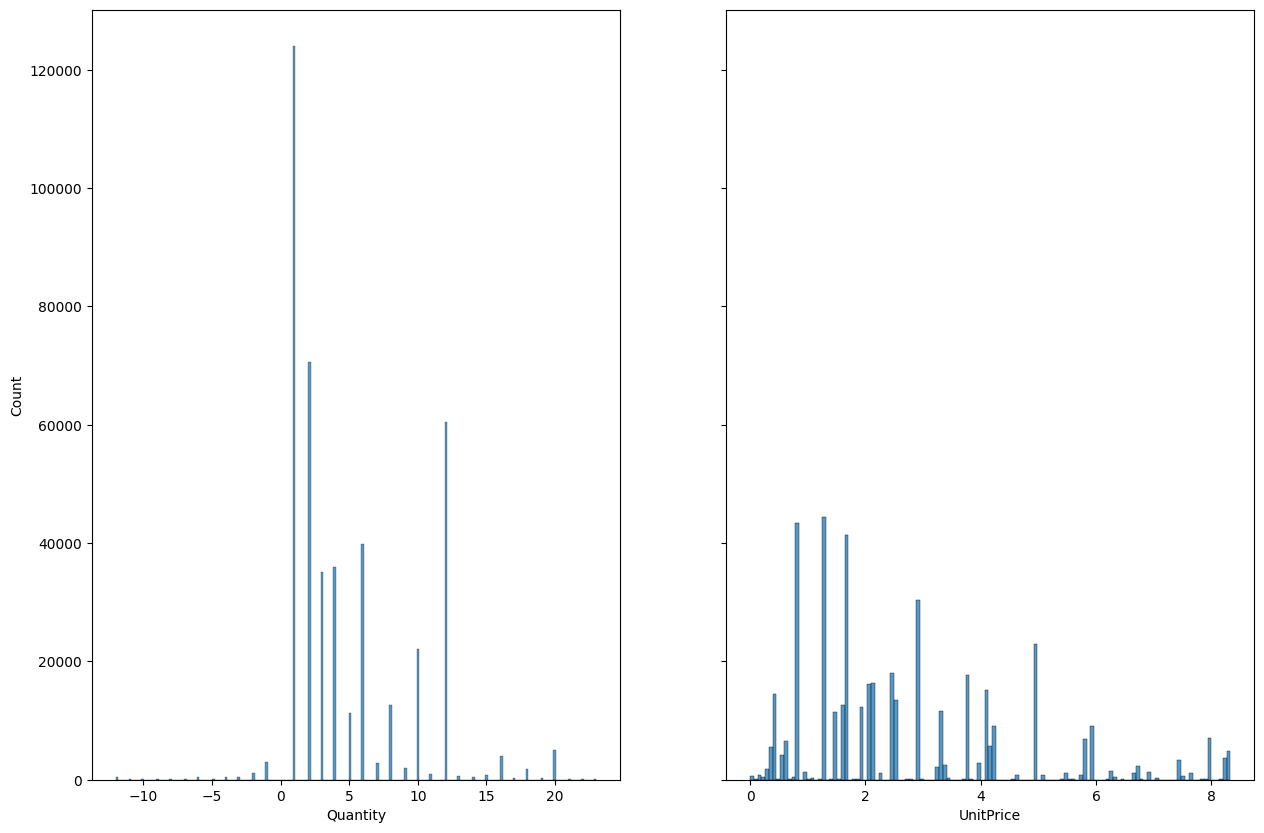

In [238]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(15, 10))
sns.histplot(df['Quantity'], ax=axes[0])
sns.histplot(df['UnitPrice'], ax=axes[1])


In [239]:
# subtract 'Year, Month, and Quarter' from the column InvoiceDate.
df['Years'] = df['InvoiceDate'].dt.year
df['Quarters'] = df['InvoiceDate'].dt.to_period('Q')
df['Months'] = df['InvoiceDate'].dt.strftime('%b-%Y')


In [240]:
#Create new column 'Total Sale'
df["TotalSales"] = df["Quantity"] * df["UnitPrice"]


In [241]:
#change the type of the columns 'Year' from int to object or string
df["Years"]=df["Years"].astype('object')


In [242]:
Years =  list(map(str, range(2010, 2012)))
Years


['2010', '2011']

# TASKE 4 EDA (Eploratory Data Analysis):
- To do an EDA (Eploratory Data Analysis), we need to reduce our data size, it's good for a fast data `visualization`.

In [243]:
# randomly choose some from dataframe
df_new = df.sample(frac=0.015, random_state=50)
df_new


,Description,Quantity,InvoiceDate,UnitPrice,Country,Years,Quarters,Months,TotalSales
391057,CHARLOTTE BAG SUKI DESIGN,10,2011-11-21 10:23:00,0.85,United Kingdom,2011,2011Q4,Nov-2011,8.50
349141,EUCALYPTUS & PINECONE WREATH,20,2011-11-02 14:50:00,2.95,United Kingdom,2011,2011Q4,Nov-2011,59.00
269787,SET 12 KIDS COLOUR CHALK STICKS,2,2011-09-12 13:43:00,0.42,United Kingdom,2011,2011Q3,Sep-2011,0.84
272498,LUNCH BAG CARS BLUE,3,2011-09-13 16:40:00,1.65,United Kingdom,2011,2011Q3,Sep-2011,4.95
404380,BALLOONS WRITING SET,3,2011-11-25 15:23:00,3.29,United Kingdom,2011,2011Q4,Nov-2011,9.87
...,...,...,...,...,...,...,...,...,...
428546,BLUE PAISLEY TISSUE BOX,1,2011-12-06 12:21:00,0.39,United Kingdom,2011,2011Q4,Dec-2011,0.39
76040,RETRO PLASTIC ELEPHANT TRAY,6,2011-02-18 13:26:00,0.85,United Kingdom,2011,2011Q1,Feb-2011,5.10
202398,POPPY'S PLAYHOUSE BEDROOM,2,2011-07-06 13:06:00,2.10,United Kingdom,2011,2011Q3,Jul-2011,4.20
422189,LARGE MEDINA STAMPED METAL BOWL,1,2011-12-04 13:00:00,4.95,United Kingdom,2011,2011Q4,Dec-2011,4.95


In [244]:
#checks our new sample
df_new.info()


<class 'pandas.core.frame.DataFrame'>
Index: 6565 entries, 391057 to 82082
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Description  6565 non-null   object        
 1   Quantity     6565 non-null   int64         
 2   InvoiceDate  6565 non-null   datetime64[ns]
 3   UnitPrice    6565 non-null   float64       
 4   Country      6565 non-null   object        
 5   Years        6565 non-null   object        
 6   Quarters     6565 non-null   period[Q-DEC] 
 7   Months       6565 non-null   object        
 8   TotalSales   6565 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4), period[Q-DEC](1)
memory usage: 512.9+ KB


In [245]:
#We explore some statistical values
df_new.describe()


,Quantity,InvoiceDate,UnitPrice,TotalSales
count,6565.000000,6565,6565.000000,6565.000000
mean,4.897182,2011-07-05 03:49:09.349581056,2.724603,10.659554
min,-12.000000,2010-12-01 09:53:00,0.000000,-71.400000
25%,1.000000,2011-03-25 12:21:00,1.250000,3.260000
50%,3.000000,2011-07-21 15:14:00,2.100000,7.460000
75%,8.000000,2011-10-19 13:58:00,3.750000,15.300000
max,21.000000,2011-12-09 12:16:00,8.290000,160.000000
std,4.668760,NaN,1.961582,11.703460


In [ ]:
#correlation matrix
df_new.select_dtypes('number').corr()


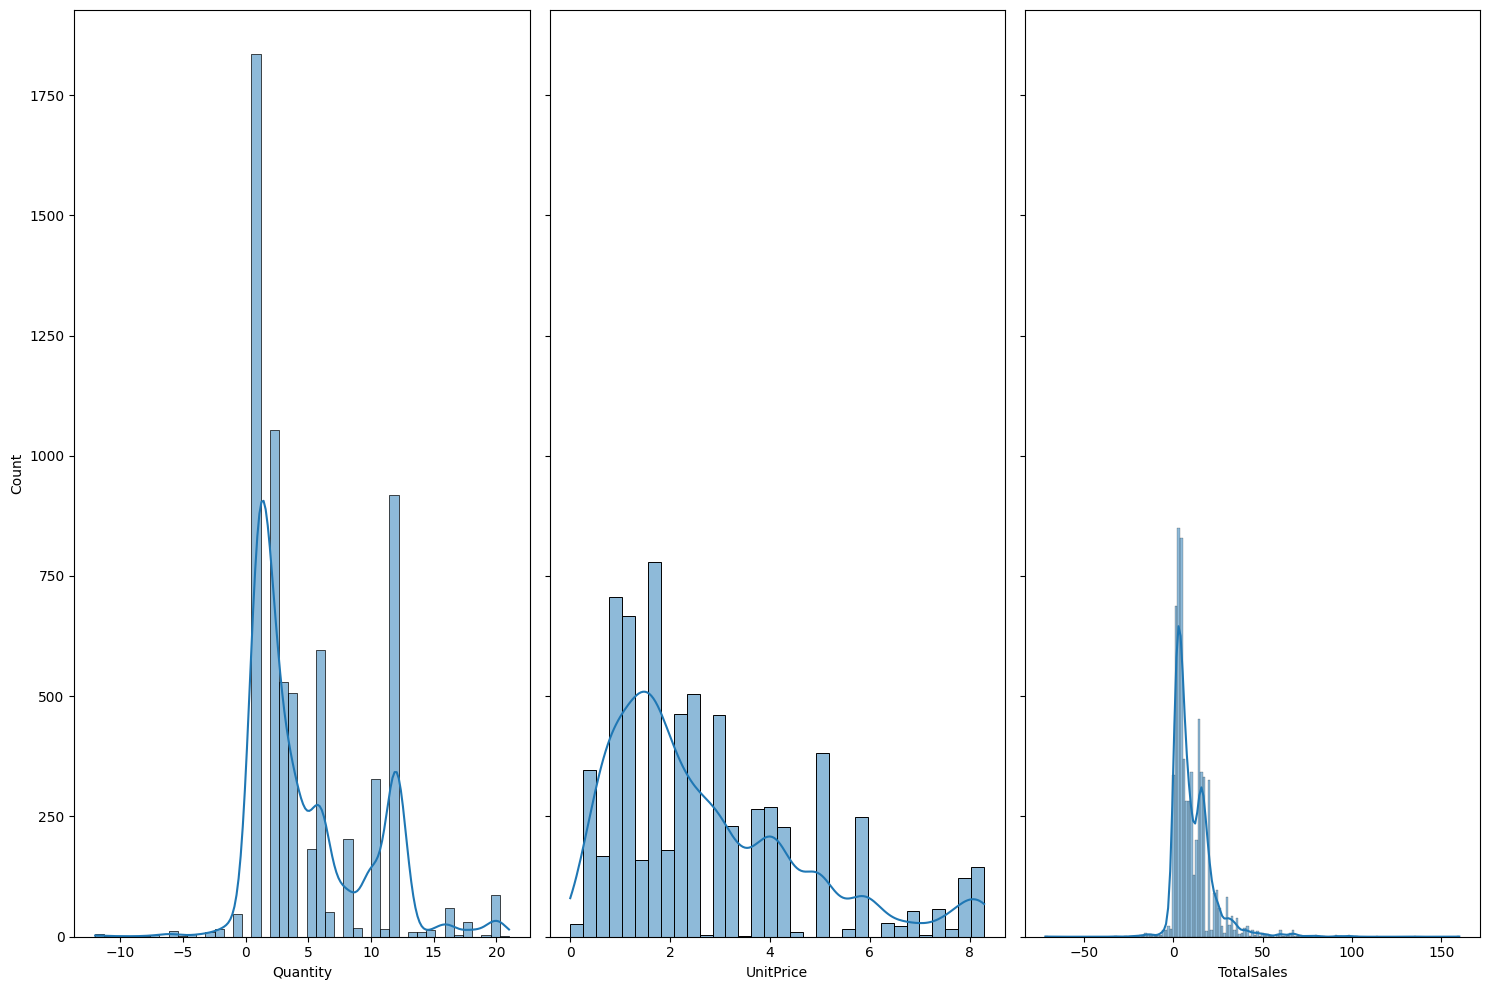

In [ ]:
# Visualize the distribution of th 'Quantity', 'Price', and 'Total sale'
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(15, 10))
sns.histplot(df_new['Quantity'], kde=True, ax=axes[0])
sns.histplot(df_new['UnitPrice'], kde=True, ax=axes[1])
sns.histplot(df_new['TotalSales'], kde=True, ax=axes[2])
plt.tight_layout()
plt.show()


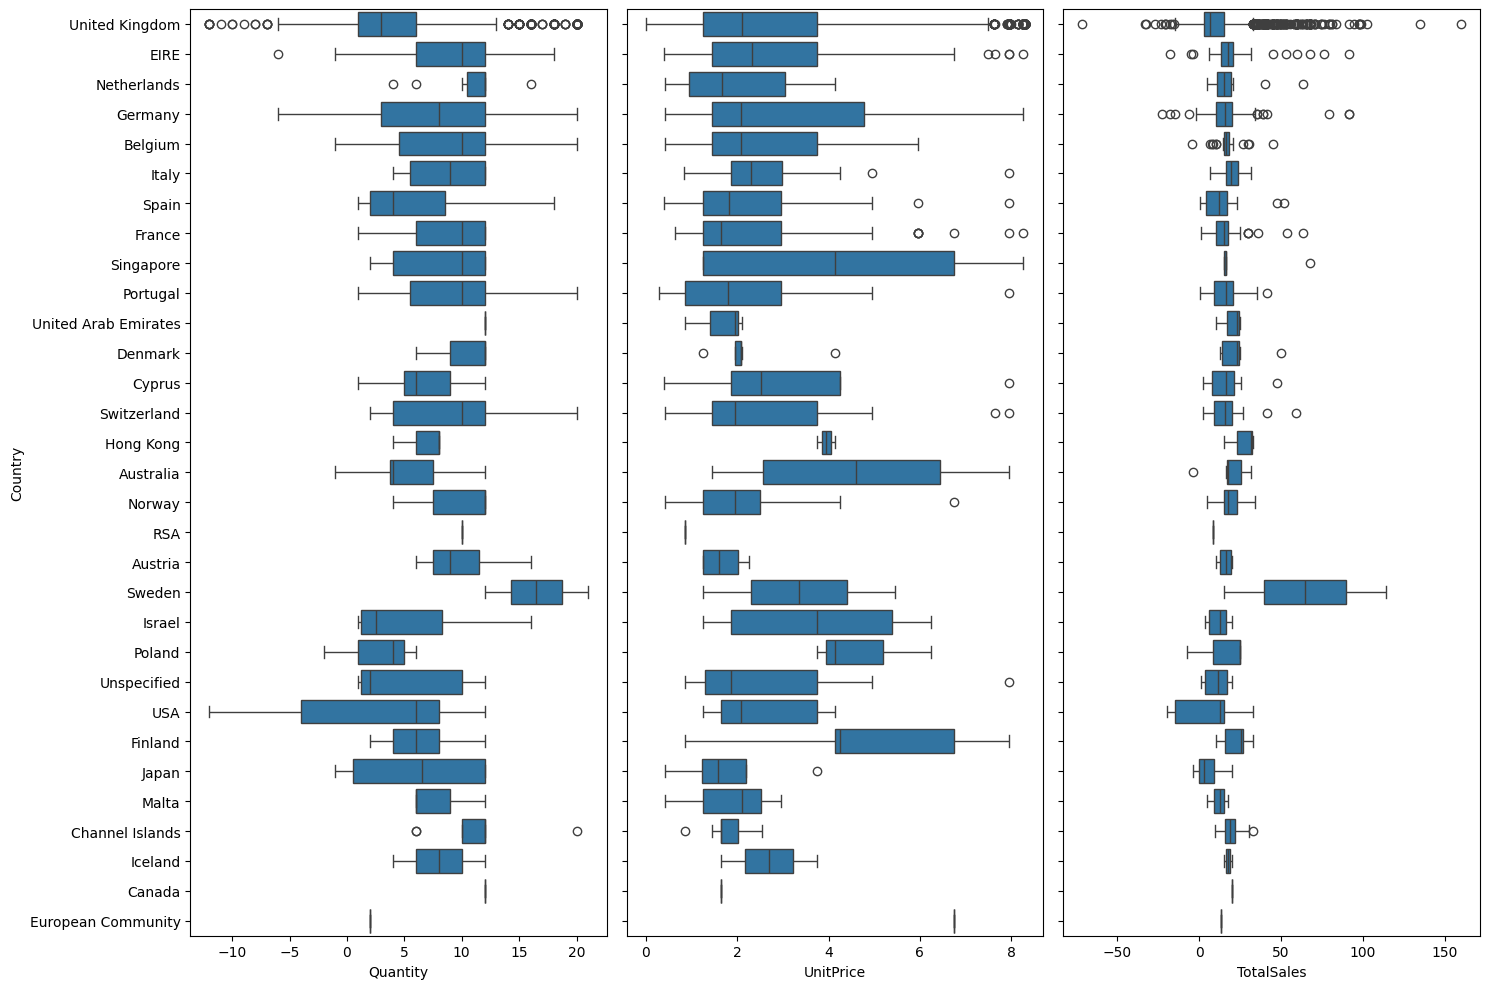

In [ ]:
# Visualize the distribution of th 'Quantity', 'Price', and 'Total sale'
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(15, 10))
sns.boxplot(x=df_new['Quantity'], y=df_new["Country"], ax=axes[0])
sns.boxplot(x=df_new['UnitPrice'], y=df_new["Country"], ax=axes[1])
sns.boxplot(x=df_new['TotalSales'], y=df_new["Country"], ax=axes[2])
plt.tight_layout()
plt.show()


- We want to know our top 15 `Products` based on `average` `TotaSales.`

In [ ]:
# Top 15 Product Sales 
df_product = df_new.groupby(["Description"], axis=0).mean('TotalSales')
df_product.reset_index(inplace=True)
df_product = df_product.sort_values(by="TotalSales", ascending=False).head(15)
df_product


/var/folders/4h/yj53d10j347dtmxsqw310m8r0000gn/T/ipykernel_880/206682235.py:2: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df_product = df_new.groupby(["Description"], axis=0).mean('TotalSales')


,Description,Quantity,UnitPrice,TotalSales
23,3 DRAWER ANTIQUE WHITE WOOD CABINET,12.000000,8.150000,97.800
26,3 HOOK PHOTO SHELF ANTIQUE WHITE,12.000000,7.650000,91.800
883,IVORY DINER WALL CLOCK,12.000000,7.650000,91.800
1082,MINT KITCHEN SCALES,12.000000,7.650000,91.800
1382,RED DINER WALL CLOCK,12.000000,7.650000,91.800
1973,WIRE EGG BASKET,12.000000,6.650000,79.800
1923,WALL ART BIG LOVE,12.000000,6.250000,75.000
1976,WOOD S/3 CABINET ANT WHITE FINISH,8.666667,8.083333,70.500
1900,VINTAGE JINGLE BELLS HEART,8.000000,8.250000,66.000
662,FOOT STOOL HOME SWEET HOME,8.000000,8.150000,65.200


- We can use a `Barplot` to visualize the `average` `TotalSales` of the Products types.

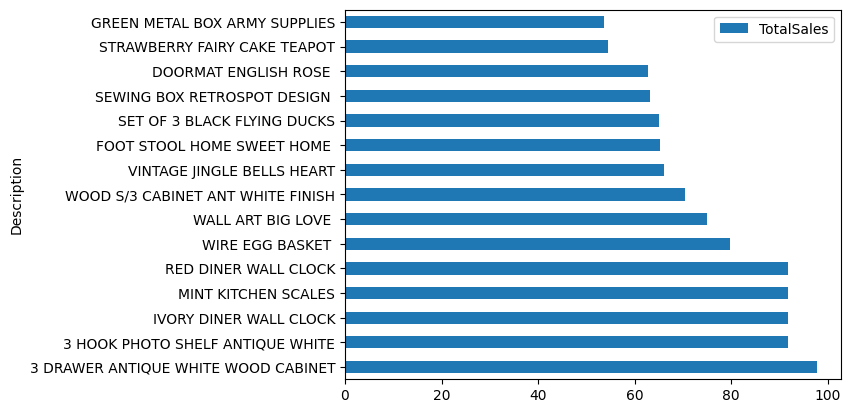

In [ ]:
# Plot a bar of the 'Top 15 Products'
df_product.plot(kind='barh',
                x='Description',
                y='TotalSales',
                )
plt.show()


- You can see on both dataframe and graph that the product that is sold the most is `3 DRAWER ANTIQUE WHITE WOOD CABINET`.

- Now we need to know the `top 6 Countries` based `average` `TotalSales`.

In [ ]:
#Determine the average values of each country
df_country = df_new.groupby("Country", axis=0).mean('TotalSales')
df_country.reset_index(inplace = True)
df_country.head()


/var/folders/4h/yj53d10j347dtmxsqw310m8r0000gn/T/ipykernel_880/526796729.py:1: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df_country = df_new.groupby("Country", axis=0).mean('TotalSales')


,Country,Quantity,UnitPrice,TotalSales
0,Australia,5.500000,4.51250,18.662500
1,Austria,10.000000,1.67500,15.750000
2,Belgium,9.096774,2.42129,16.936774
3,Canada,12.000000,1.65000,19.800000
4,Channel Islands,11.200000,1.79300,19.570000


In [ ]:
#Determine the top 6 Countries 
df_country_top6 = df_country.sort_values(by='TotalSales', ascending=False).head(6)
df_country_top6


,Country,Quantity,UnitPrice,TotalSales
25,Sweden,16.500000,3.350000,64.725000
12,Hong Kong,6.666667,3.950000,26.600000
23,Singapore,8.000000,4.330000,26.120000
6,Denmark,10.285714,2.222857,23.091429
9,Finland,6.400000,4.790000,22.360000
18,Netherlands,10.800000,1.982000,20.368000


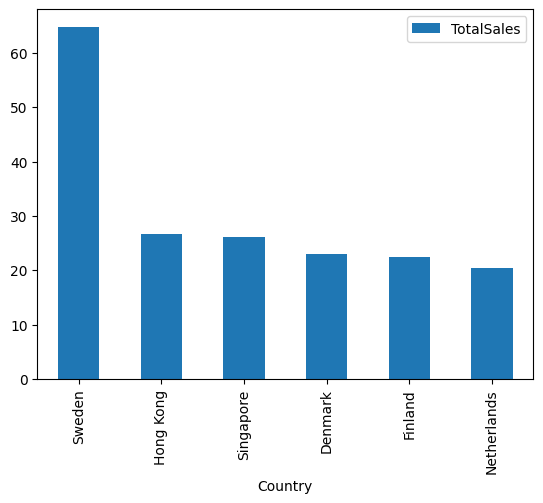

In [ ]:
#Plot to visualize the top 6 Countries using Barplot
df_country_top6.plot(
    kind="bar",
    x="Country",
    y="TotalSales"
)
plt.show()


In [ ]:
#Sort Values by Years in descendin order
df_new.sort_values(by="Years", ascending=True, inplace=True)
df_new.head()


,Description,Quantity,InvoiceDate,UnitPrice,Country,Years,Quarters,Months,TotalSales
1549,PINK HEART SHAPE LOVE BUCKET,2,2010-12-01 14:32:00,5.91,United Kingdom,2010,2010Q4,Dec-2010,11.82
15191,MINI JIGSAW SPACEBOY,1,2010-12-08 14:25:00,0.85,United Kingdom,2010,2010Q4,Dec-2010,0.85
23614,DOLLY GIRL LUNCH BOX,1,2010-12-14 11:26:00,1.95,United Kingdom,2010,2010Q4,Dec-2010,1.95
20999,ALARM CLOCK BAKELIKE IVORY,1,2010-12-12 12:44:00,3.75,United Kingdom,2010,2010Q4,Dec-2010,3.75
22019,CORONA MEXICAN TRAY,12,2010-12-13 10:31:00,3.75,United Kingdom,2010,2010Q4,Dec-2010,45.00


In [ ]:
#Turn dates into sting
df_new["Years"] = df_new["Years"].astype(str)
df_new["Quarters"] = df_new["Quarters"].astype(str)
df_new["Months"] = df_new["Months"].astype(str)


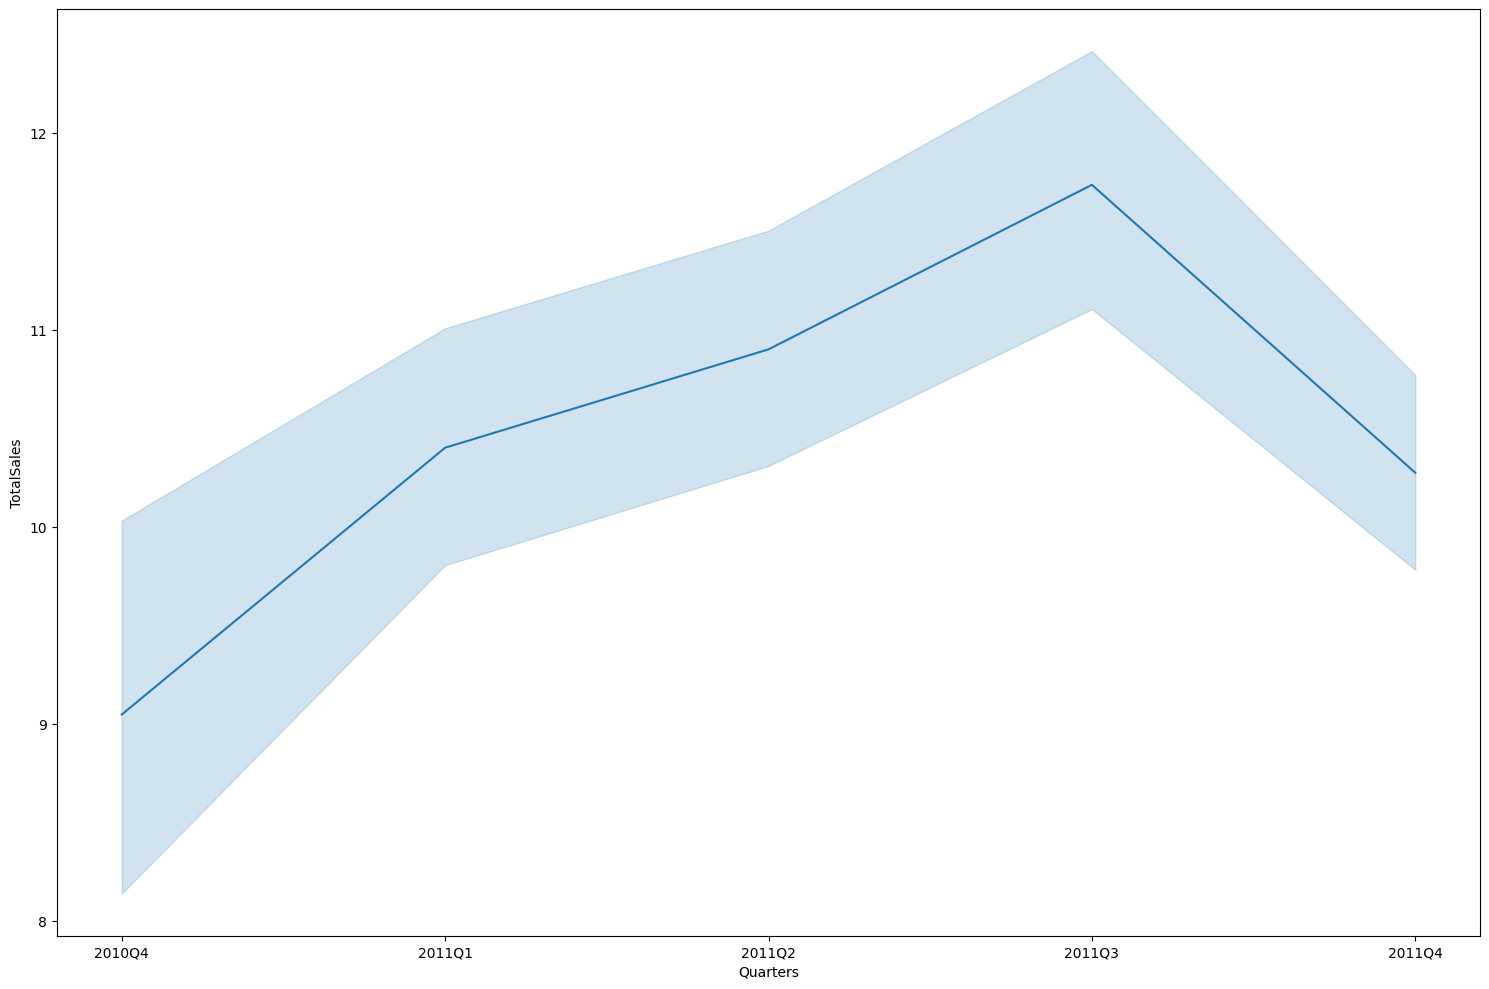

In [ ]:
# Plot The Quaterly Sales with the line plot
plt.figure(figsize=(15, 10))
sns.lineplot(
    data=df_new,
    x= "Quarters",
    y= "TotalSales",
)


plt.tight_layout()
plt.show()


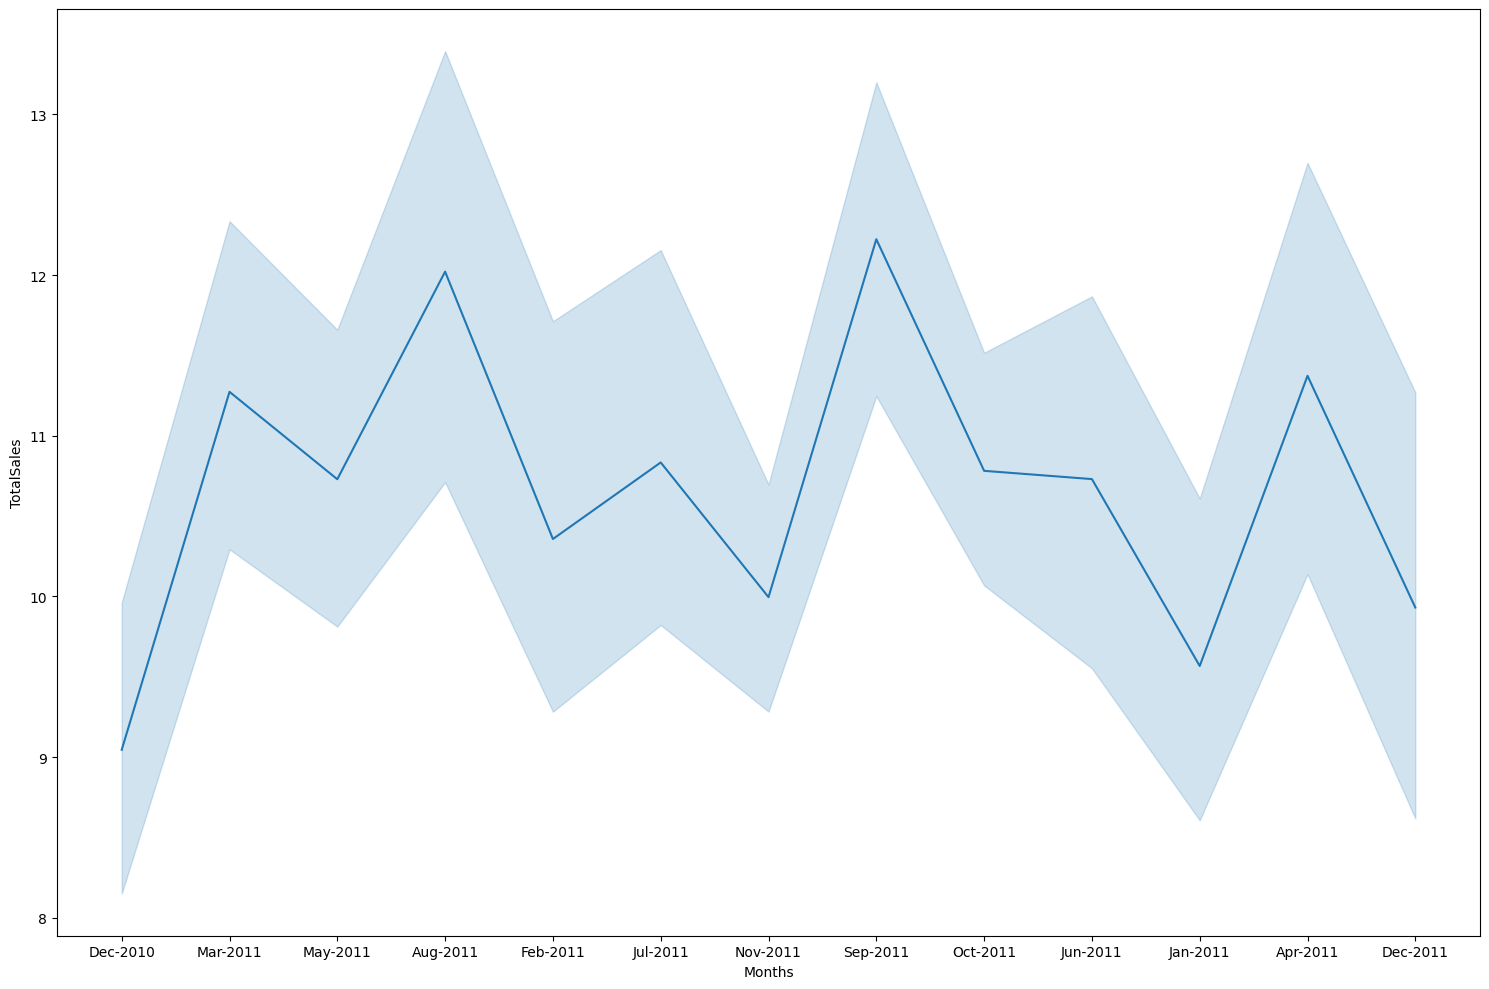

In [ ]:
#Plot The monthly Sales with the line plot
plt.figure(figsize=(15, 10))
sns.lineplot(
    data=df_new,
    x= "Months",
    y= "TotalSales",
)


plt.tight_layout()
plt.show()


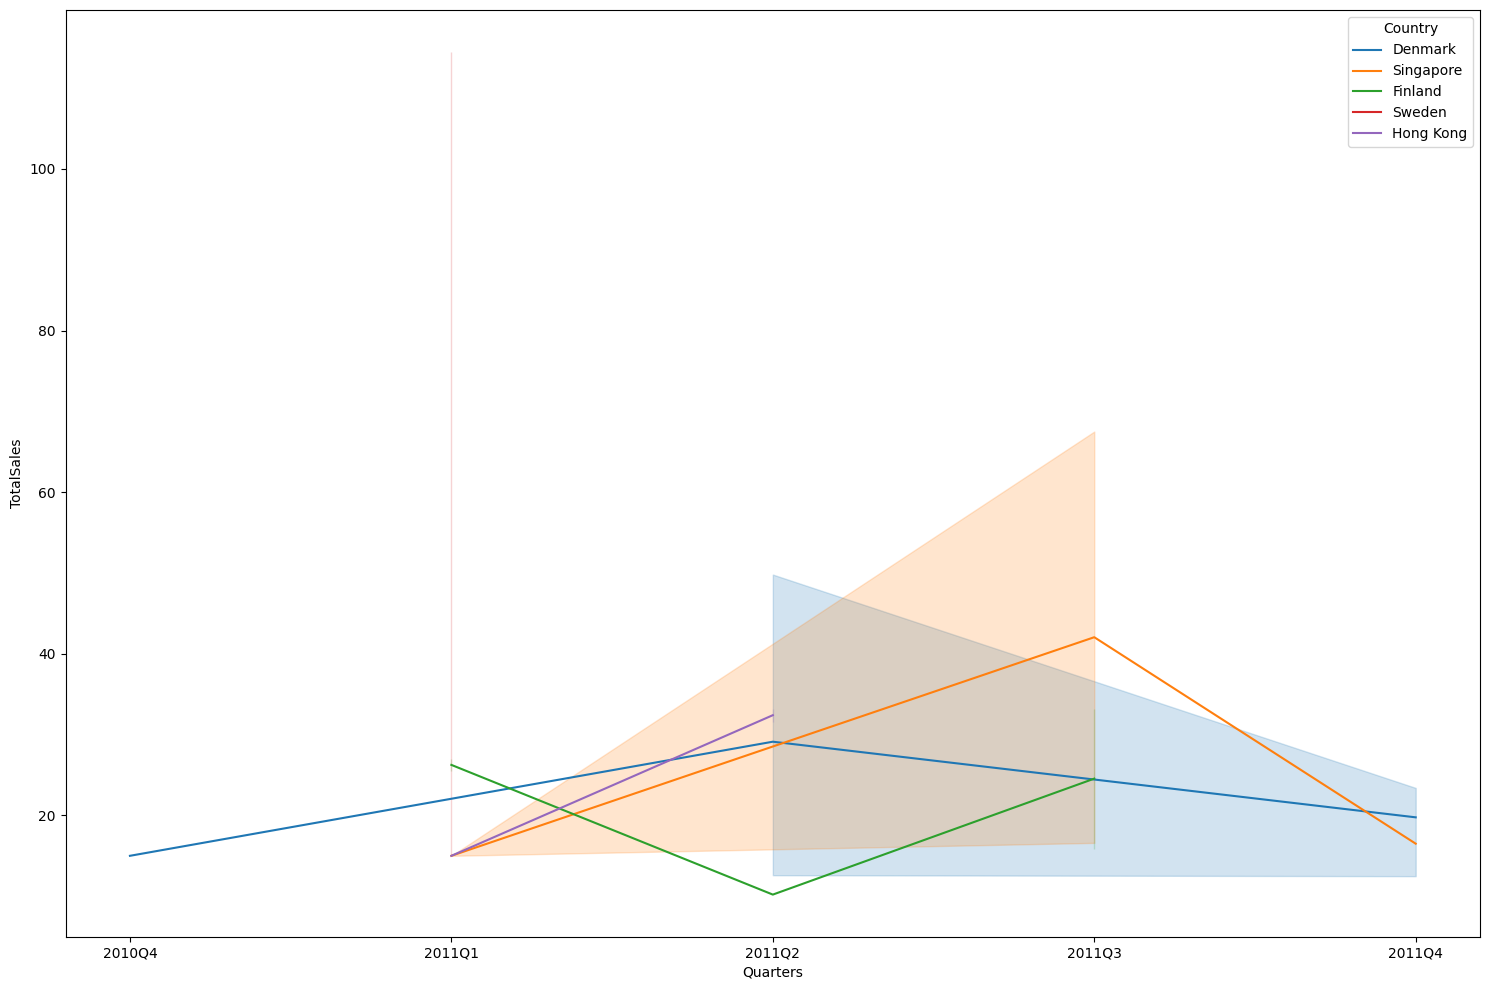

In [ ]:
#Determine the top 5 countries with the most total Sales
df_top5 = df_new[(df_new["Country"]=="Sweden") | (df_new["Country"]=="Denmark") |
                 (df_new["Country"]=="Hong Kong") | (df_new["Country"]=="Singapore")|
                 (df_new["Country"]=="Finland")
                 ]

#plot The top 5 countries with the most total Sales
plt.figure(figsize=(15, 10))
sns.lineplot(
    data=df_top5,
    x="Quarters",
    y="TotalSales",
    hue="Country"
)

plt.tight_layout()
plt.show()
